In [1]:
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Datasheet/credit_card_fraud_10k.csv'

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [3]:
df.drop(columns='transaction_id', inplace=True)

In [4]:
df.head(5)

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


In [5]:
df.isnull().sum()

,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [6]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [7]:
df['is_fraud'].value_counts(normalize=True)*100

,proportion
is_fraud,
0,98.49
1,1.51


**Feature Engineering**

In [8]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['transaction_hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['transaction_hour']/24)

In [9]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud', 'hour_sin',
       'hour_cos'],
      dtype='object')

**Preprocessing**

In [10]:
Feature = ['amount','hour_sin','hour_cos','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h','cardholder_age']
X = df[Feature]
y = df['is_fraud']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)
print(f"Jumlah data training :{len(X_train)} dan jumlah data uji :{len(X_test)}")

Jumlah data training :8000 dan jumlah data uji :2000


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_feature = ['amount','device_trust_score','velocity_last_24h','cardholder_age']
num_transform = scaler

In [13]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_transform, num_feature)
], remainder = 'passthrough')

In [14]:
from sklearn.ensemble import RandomForestClassifier

baseline_rf = RandomForestClassifier(random_state=42)

**Model Baseline**

In [15]:
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', baseline_rf)
])

In [16]:
baseline_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [17]:
y_pred_baseline = baseline_pipeline.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
print(f"Akurasi baseline dari data uji adalah : {accuracy_baseline:.4f}")
print(f"Precision baseline dari data uji adalah : {precision_baseline:.4f}")
print(f"Recall baseline dari data uji adalah : {recall_baseline:.4f}")
print(classification_report(y_test, y_pred_baseline))

Akurasi baseline dari data uji adalah : 0.9945
Precision baseline dari data uji adalah : 1.0000
Recall baseline dari data uji adalah : 0.6333
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.63      0.78        30

    accuracy                           0.99      2000
   macro avg       1.00      0.82      0.89      2000
weighted avg       0.99      0.99      0.99      2000



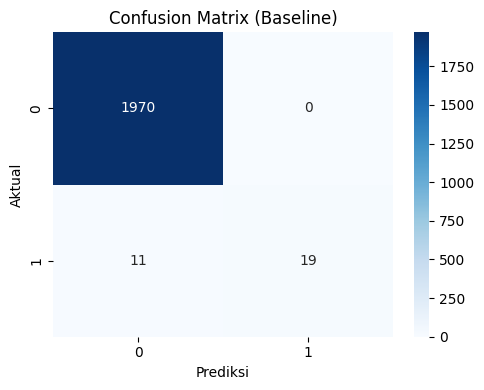

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, fmt='d', annot=True, cmap='Blues')
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [20]:
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:,1]
roc_auc_baseline = roc_auc_score(y_test, y_prob_baseline)
print(roc_auc_baseline)

0.9998730964467005


**Random Forest + Class Weight**

In [21]:
balanced_rf = RandomForestClassifier(random_state=42, class_weight='balanced')

In [22]:
balanced_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', balanced_rf)
])

In [23]:
balanced_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [24]:
y_pred_balanced = balanced_pipeline.predict(X_test)

In [25]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
print(f'Akurasi balanced dari data uji adalah: {accuracy_balanced:.4f}')
print(f'Precision score balanced dari data uji adalah: {precision_balanced:.4f}')
print(f'Recall score balanced dari data uji adalah :{recall_balanced:.4f}')
print(classification_report(y_test, y_pred_balanced))

Akurasi balanced dari data uji adalah: 0.9935
Precision score balanced dari data uji adalah: 1.0000
Recall score balanced dari data uji adalah :0.5667
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.57      0.72        30

    accuracy                           0.99      2000
   macro avg       1.00      0.78      0.86      2000
weighted avg       0.99      0.99      0.99      2000



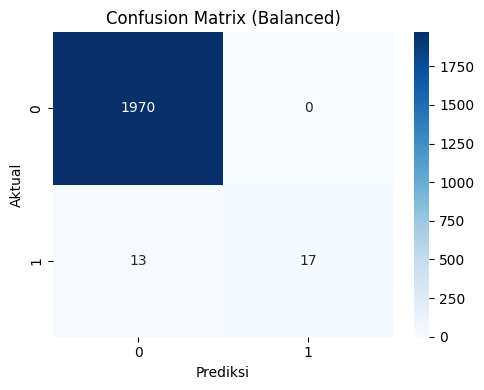

In [26]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(5,4))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Balanced)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [27]:
y_prob_balanced = balanced_pipeline.predict_proba(X_test)[:,1]
roc_auc_balanced = roc_auc_score(y_test, y_prob_balanced)
print(roc_auc_balanced)

0.9997969543147208


**Random Forest + SMOTE**

In [28]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', baseline_rf)
])

In [29]:
smote_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', RandomForestClassifier(random_state=42))])

In [30]:
y_pred_smote = smote_pipeline.predict(X_test)

In [31]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
print(f'Akurasi dengan smote pada data uji : {accuracy_smote:.4f}')
print(f'Precision dengan smote pada data uji : {precision_smote:.4f}')
print(f'Recall dengan smote pada data uji : {recall_smote:.4f}')
print(classification_report(y_test, y_pred_smote))

Akurasi dengan smote pada data uji : 0.9980
Precision dengan smote pada data uji : 0.9643
Recall dengan smote pada data uji : 0.9000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.96      0.90      0.93        30

    accuracy                           1.00      2000
   macro avg       0.98      0.95      0.97      2000
weighted avg       1.00      1.00      1.00      2000



In [32]:
y_prob_smote = smote_pipeline.predict_proba(X_test)[:,1]
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)
print(roc_auc_smote)

0.9997715736040609


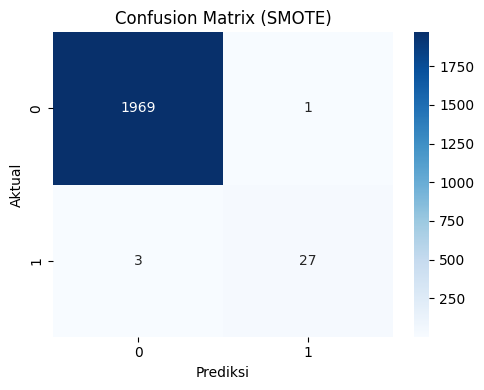

In [33]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SMOTE)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

**Model Hyperparameter Tuning Menggunakan Model SMOTE**

In [34]:
params_grid = {
    'model__n_estimators': [100,200],
    'model__criterion': ['gini','entropy'],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features' : ['sqrt','log2']
}

In [35]:
from sklearn.model_selection import GridSearchCV

grid_rf = GridSearchCV(
    estimator=smote_pipeline,
    param_grid=params_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=3
)

In [36]:
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['amount',
                                                                          'device_trust_score',
                                                                          'velocity_last_24h',
                                                                          'cardholder_age'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [None, 10, 20],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200]},
             scoring='f1', verbose=3)

In [37]:
print(grid_rf.best_params_)

{'model__criterion': 'entropy', 'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [38]:
best_rf = grid_rf.best_estimator_

In [39]:
y_pred = best_rf.predict(X_test)

In [40]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'Akurasi pada data uji adalah :{accuracy:.4f}')
print(f'Precision pada data uji adalah :{precision:.4f}')
print(f'Recall pada data uji adalah :{recall:.4f}')
print(classification_report(y_test, y_pred))

Akurasi pada data uji adalah :0.9985
Precision pada data uji adalah :0.9355
Recall pada data uji adalah :0.9667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.94      0.97      0.95        30

    accuracy                           1.00      2000
   macro avg       0.97      0.98      0.98      2000
weighted avg       1.00      1.00      1.00      2000



In [41]:
y_prob = best_rf.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print(roc_auc)

0.9999492385786801


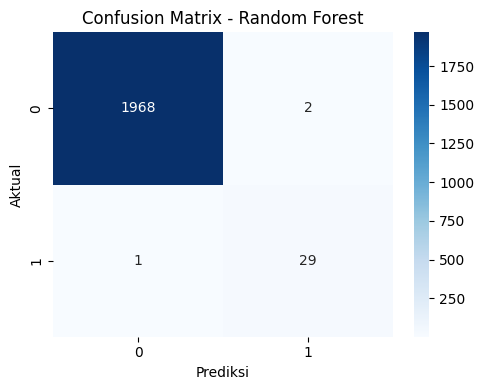

In [48]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [43]:
features_names = X_train.columns
rf_model = best_rf.named_steps['model']
importance = rf_model.feature_importances_

In [44]:
feature_importance = pd.DataFrame({
    'Feature': features_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [45]:
feature_importance

,Feature,Importance
1,hour_sin,0.234708
5,device_trust_score,0.199736
6,velocity_last_24h,0.173494
2,hour_cos,0.148643
7,cardholder_age,0.139018
4,location_mismatch,0.066438
0,amount,0.028482
3,foreign_transaction,0.009481


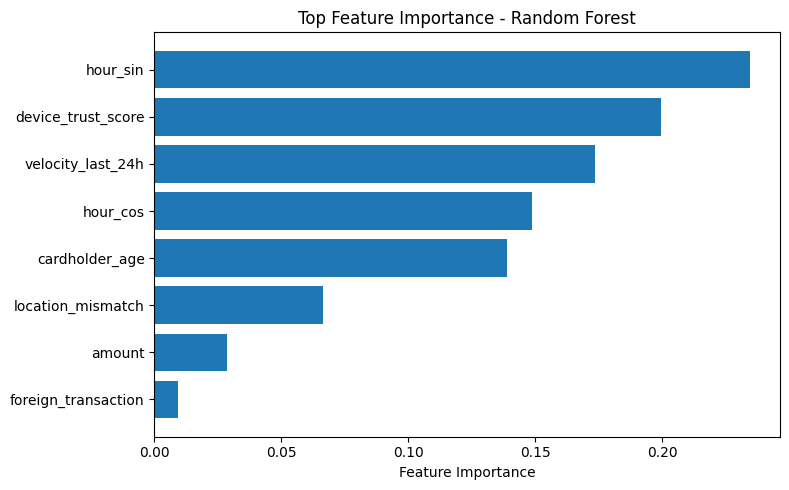

In [46]:
plt.figure(figsize=(8,5))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel('Feature Importance')
plt.title('Top Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [47]:
from google.colab import files
import joblib

joblib.dump(best_rf,'Random_Forest_Model.joblib')
files.download('Random_Forest_Model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>